<a href="https://colab.research.google.com/github/cermegno/langgraph-learning/blob/main/graph1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Review
Let's review important 'typing' concepts. Typed dictionaries are used to create the graph state to prevent errors in the graph. Also, reviewing lambda and map



In [18]:
from typing import TypedDict, Union, Optional, Any

class Movie(TypedDict):
    title: str
    director: str
    year: int
    rating: Union[float, str]

movie = Movie(title="The Matrix", director="Lana Wachowski", year=1999, rating="a")
print(movie)

def describe_movie(movie: Movie, commentary: Optional[str]) -> None:
    print(f"{movie['title']} ({movie['year']}), by {movie['director']}: {commentary}")

describe_movie(movie, "Great movie!")
describe_movie(movie, None)

def echo_echo(thing: Any) -> None:
    print(thing)

echo_echo(5)
echo_echo("Hello")
echo_echo([1, 2, 3])
echo_echo(movie)

{'title': 'The Matrix', 'director': 'Lana Wachowski', 'year': 1999, 'rating': 'a'}
The Matrix (1999), by Lana Wachowski: Great movie!
The Matrix (1999), by Lana Wachowski: None
5
Hello
[1, 2, 3]
{'title': 'The Matrix', 'director': 'Lana Wachowski', 'year': 1999, 'rating': 'a'}


Review 'map' and 'lambda'

In [19]:
nums = [1, 2, 3, 4]
squares = list(map(lambda x: x * x, nums))
print(squares)

[1, 4, 9, 16]


# Graph 1

In [20]:
!pip install langgraph

In [33]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [35]:
class AgentState(TypedDict):
  message: str

def greeting_func(state: AgentState) -> AgentState:
  """Node that greets the user"""
  state["message"] = "Hello " + state["message"] + "! How can I help you?"
  return state



Test the class and the node function

In [36]:
test = AgentState(message="Tim")
greeting_func(test)

{'message': 'Hello Tim! How can I help you?'}

We are ready to build the **Graph**

In [42]:
graph = StateGraph(AgentState)
graph.add_node("greeting_node", greeting_func)
graph.add_edge(START, "greeting_node")
graph.add_edge("greeting_node", END)
app = graph.compile()

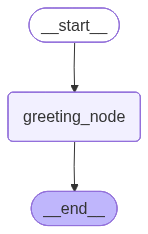

In [44]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [46]:
response = app.invoke({"message": "Tim"})
print(response)

{'message': 'Hello Tim! How can I help you?'}
